In [ ]:
# TY Claude :3

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("mps")

In [ ]:
T = 1000


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
dataset = torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0)

In [ ]:
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

def q_sample(x0, t, noise):
    s1 = alpha_bar[t].sqrt().view(-1, 1, 1, 1)
    s2 = (1 - alpha_bar[t]).sqrt().view(-1, 1, 1, 1)
    return s1 * x0 + s2 * noise

In [ ]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        groups = min(8, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm = nn.GroupNorm(groups, out_ch)
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t):
        h = F.relu(self.conv1(x))
        h = h + self.t_proj(t)[:, :, None, None]
        h = F.relu(self.norm(self.conv2(h)))
        return h + self.skip(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.t_emb = nn.Sequential(
            nn.Embedding(T, 128),
            nn.Linear(128, 128),
            nn.ReLU(),
        )

        self.enc1 = Block(1,   64,  128)
        self.enc2 = Block(64,  128, 128)
        self.down1 = nn.Conv2d(64,  64,  3, stride=2, padding=1)
        self.down2 = nn.Conv2d(128, 128, 3, stride=2, padding=1)

        self.mid = Block(128, 128, 128)

        self.up1 = nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1)
        self.dec1 = Block(256, 64,  128)
        self.up2 = nn.ConvTranspose2d(64,  64,  4, stride=2, padding=1)
        self.dec2 = Block(128, 64,  128)
        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x, t):
        t = self.t_emb(t)
        e1 = self.enc1(x, t)
        e2 = self.enc2(self.down1(e1), t)
        m = self.mid(self.down2(e2), t)
        d = self.dec1(torch.cat([self.up1(m), e2], dim=1), t)
        d = self.dec2(torch.cat([self.up2(d), e1], dim=1), t)
        return self.out(d)


model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters())
loss_fn = nn.MSELoss()


Parameters: 1,598,145


In [ ]:
import tqdm

for epoch in range(30):
    model.train()
    total = 0.0
    for imgs, _ in tqdm.tqdm(loader):
        imgs = imgs.to(device)
        t = torch.randint(0, T, (imgs.size(0),), device=device)
        noise = torch.randn_like(imgs)
        noisy = q_sample(imgs, t, noise)

        loss = loss_fn(model(noisy, t), noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total += loss.item()

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  loss={total/len(loader):.4f}')

Epoch   1/30  loss=0.1112


KeyboardInterrupt: 

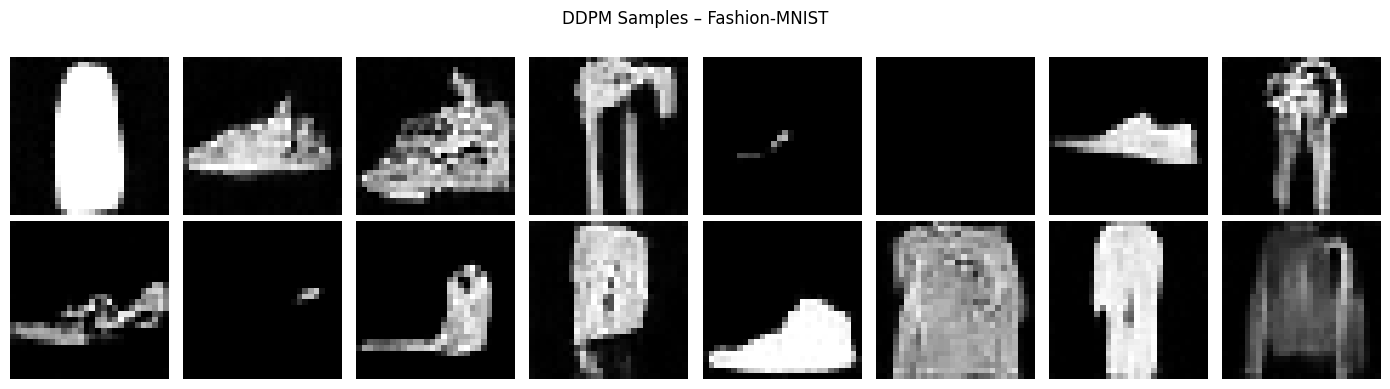

In [ ]:
@torch.no_grad()

def sample(n): #ty claude
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        eps = model(x, t_batch)

        beta_t = betas[t]
        alpha_t = alphas[t]
        ab_t = alpha_bar[t]
        mean = (x - beta_t / (1 - ab_t).sqrt() * eps) / alpha_t.sqrt()
        if t > 0:
            ab_prev = alpha_bar[t - 1]
            var = beta_t * (1 - ab_prev) / (1 - ab_t)
            mean = mean + var.sqrt() * torch.randn_like(x)
        x = mean
    return (x.clamp(-1, 1) + 1) / 2   # → [0, 1]


samples = sample(16).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.suptitle('DDPM Samples – Fashion-MNIST')
plt.tight_layout()
plt.show()